# Capstone 2: Business Analysis with Python
# EmporiUm Sales Territory Analysis — Northeast Region

**Analyst:** Mohamed Mouatakid  
**Week:** 8  

# Sales Territories Being Analyzed:
| Territory         | State            | Territory Manager |
|-----------|-------|------------------|
| Sales Territory 1 | Maine            | Erbayne Middleton |
| Sales Territory 2 | Maryland         | Shruti Reddy |


# Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Step 2 — Load and Inspect Data

In [7]:
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.columns = customer_list.columns.str.strip()
customer_list.info()
customer_list.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   cust_id      521 non-null    int64 
 1   date         521 non-null    object
 2   time         521 non-null    object
 3   name         521 non-null    object
 4   email        521 non-null    object
 5   phone        520 non-null    object
 6   sms-opt-out  520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [8]:
product_categories = pd.read_csv('ProductCategories.csv')
product_categories.info()
product_categories.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [9]:
products = pd.read_csv('Products.csv')
products.info()
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [5]:
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()
store_detail.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [10]:
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()
store_sales.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


# Core Marketing Analysis

# Question 1 — Territory Managers & Store Information

In [12]:
my_states = ['Maine', 'Maryland']
my_stores = store_detail[store_detail['State'].isin(my_states)].copy()

for state in my_states:
    state_stores = my_stores[my_stores['State'] == state]
    manager = state_stores['Territory Manager'].iloc[0]
    print(f"{'='*50}")
    print(f"  Territory: {state}")
    print(f"  Territory Manager: {manager}")
    print(f"{'='*50}")
    print(state_stores[['Store ID', 'Store Location']].to_string(index=False))
    print()

  Territory: Maine
  Territory Manager: Erbayne Middleton
 Store ID Store Location
      818         Bangor
      819     Bar Harbor
      820  Kennebunkport
      821       Lewiston
      822          Orono
      823 South Portland

  Territory: Maryland
  Territory Manager: Shruti Reddy
 Store ID      Store Location
      731           Annapolis
      732          Back River
      733           Baltimore
      734          Germantown
      735              Howard
      736       North Harford
      737           Parkville
      738 Queen Anne's County
      739             Ridgely



# Question 2 — Monthly Total Revenue
What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?

In [13]:
# Get store IDs for our territories
my_store_ids = my_stores['Store ID'].tolist()

# Filter sales to our territory stores only
my_sales = store_sales[store_sales['Store ID'].isin(my_store_ids)].copy()

# Parse transaction date and extract month
my_sales['Transaction Date'] = pd.to_datetime(my_sales['Transaction Date'])
my_sales['Month'] = my_sales['Transaction Date'].dt.to_period('M')

# Merge with store details to know which state each sale belongs to
my_sales_detail = my_sales.merge(
    my_stores[['Store ID', 'Store Location', 'State', 'Territory Manager']],
    on='Store ID'
)

print(f"Total transactions in our territories: {len(my_sales_detail):,}")
print(f"Date range: {my_sales['Transaction Date'].min().date()} to {my_sales['Transaction Date'].max().date()}")

Total transactions in our territories: 102,709
Date range: 2022-01-01 to 2025-12-31


In [14]:
# Calculate monthly revenue per territory
monthly_revenue = my_sales_detail.groupby(
    ['State', 'Month'])['Sale Amount'].sum().reset_index()

# Display monthly revenue for each territory
for state in my_states:
    df = monthly_revenue[monthly_revenue['State'] == state].sort_values('Month')
    print(f"\n{'='*45}")
    print(f"  {state} — Monthly Revenue")
    print(f"{'='*45}")
    print(df[['Month', 'Sale Amount']].to_string(index=False))
    print(f"\n  Total Revenue: ${df['Sale Amount'].sum():,.2f}")
    print(f"  Average Monthly: ${df['Sale Amount'].mean():,.2f}")
    print(f"  Best Month:  {df.loc[df['Sale Amount'].idxmax(), 'Month']} — ${df['Sale Amount'].max():,.2f}")
    print(f"  Worst Month: {df.loc[df['Sale Amount'].idxmin(), 'Month']} — ${df['Sale Amount'].min():,.2f}")


  Maine — Monthly Revenue
  Month  Sale Amount
2022-01     15700.31
2022-02     21008.29
2022-03     23173.23
2022-04     20169.19
2022-05     22631.11
2022-06     31573.93
2022-07     19371.11
2022-08     27979.07
2022-09     27393.30
2022-10     24947.09
2022-11     19783.08
2022-12     25345.23
2023-01     41331.95
2023-02     37650.30
2023-03     36162.92
2023-04     35875.41
2023-05     26201.22
2023-06     30183.66
2023-07     44731.17
2023-08     42202.08
2023-09     44862.59
2023-10     34905.29
2023-11     35428.88
2023-12     41279.32
2024-01     43881.68
2024-02     31494.48
2024-03     36311.69
2024-04     25764.94
2024-05     31426.20
2024-06     43488.63
2024-07     42202.08
2024-08     46505.54
2024-09     33262.34
2024-10     36520.57
2024-11     40187.63
2024-12     41331.95
2025-01     45308.75
2025-02     51793.28
2025-03     45762.66
2025-04     63103.49
2025-05     46499.27
2025-06     57053.98
2025-07     59531.02
2025-08     61070.43
2025-09     48485.08
2025-10


The data covers the full period from **January 2022 to December 2025** (48 months).

                | Maine         | Maryland |
| Total Revenue | $1,877,249.75 | $11,451,615.09 |
| Average Monthly Revenue | $39,109.37 | $238,575.31 |
| Best Month | Oct 2025 — $93,456.68 | Oct 2025 — $359,699.69 |
| Worst Month | Jan 2022 — $15,700.31 | Sep 2022 — $158,952.74 |

**Key Observations:**
- Maryland generates significantly more revenue than Maine — roughly **6x more** per month on average
- Both territories show a clear **upward trend** from 2022 to 2025
- Both territories peaked in **October 2025**
- Maine started very low in early 2022 but grew consistently year over year

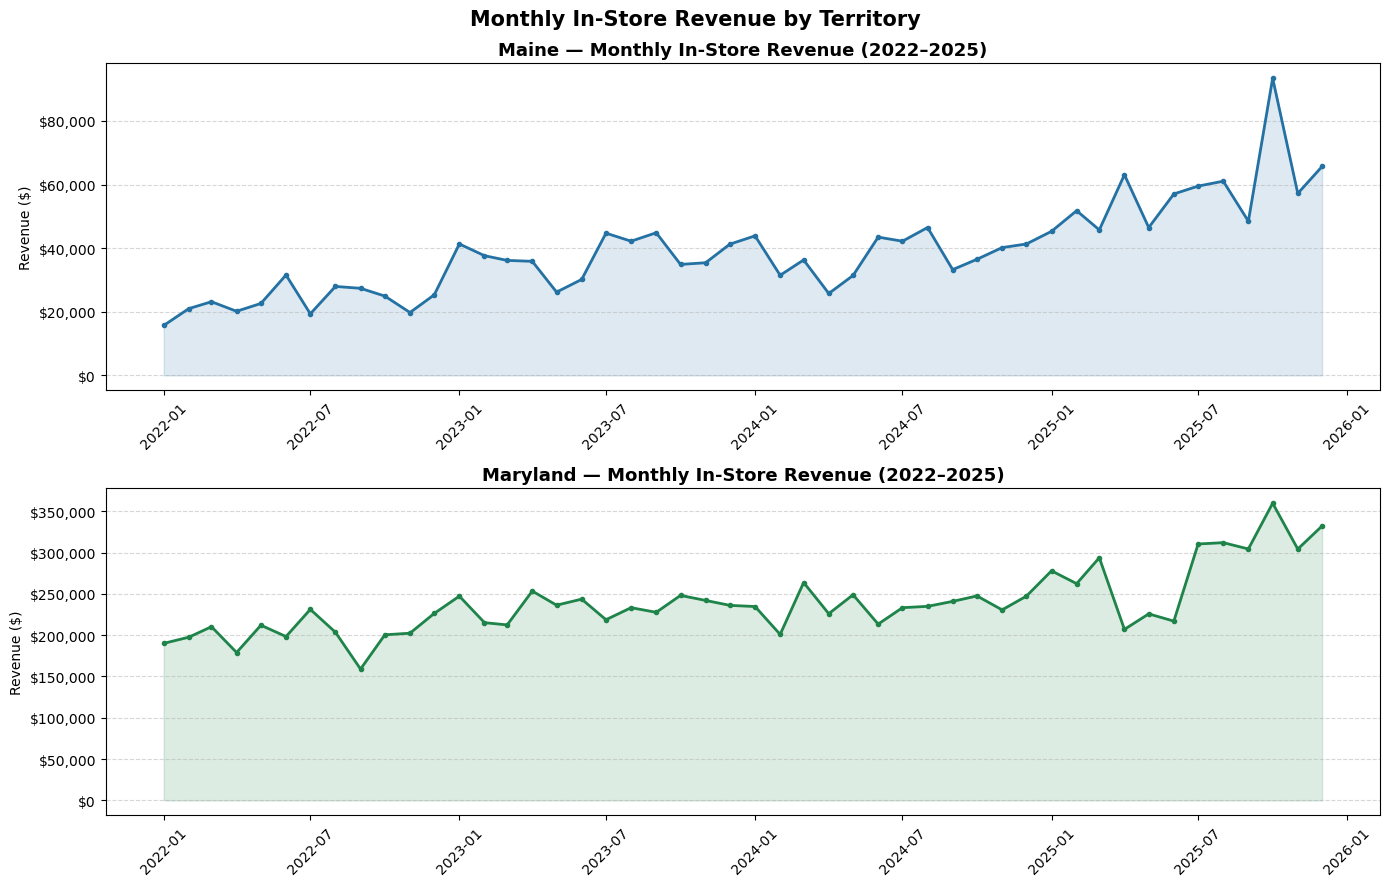

Chart saved!


In [16]:
# Chart 1: Monthly Revenue Over Time by Territory
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
colors = {'Maine': '#2471A3', 'Maryland': '#1E8449'}

for i, state in enumerate(my_states):
    df = monthly_revenue[monthly_revenue['State'] == state].sort_values('Month')
    df['Month_dt'] = df['Month'].dt.to_timestamp()
    
    axes[i].plot(df['Month_dt'], df['Sale Amount'], 
                 color=colors[state], linewidth=2, marker='o', markersize=3)
    axes[i].fill_between(df['Month_dt'], df['Sale Amount'], 
                         alpha=0.15, color=colors[state])
    axes[i].set_title(f'{state} — Monthly In-Store Revenue (2022–2025)', 
                      fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Revenue ($)', fontsize=10)
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Monthly In-Store Revenue by Territory', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', bbox_inches='tight', dpi=150)
plt.show()
print("Chart saved!")